In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


In [31]:
data=pd.read_csv("balance-scale.csv")
print(" Frist Fives record ")
print(data.head())
print(" Last Few Data")
print(data.tail())

 Frist Fives record 
  Class  L-Weight  L-Distance  R-Weight  R-Distance
0     B         1           1         1           1
1     R         1           1         1           2
2     R         1           1         1           3
3     R         1           1         1           4
4     R         1           1         1           5
 Last Few Data
    Class  L-Weight  L-Distance  R-Weight  R-Distance
620     L         5           5         5           1
621     L         5           5         5           2
622     L         5           5         5           3
623     L         5           5         5           4
624     B         5           5         5           5


In [33]:
x=data.iloc[:,1:5]
x
y=data.iloc[:,0]
y

,Class
0,B
1,R
2,R
3,R
4,R
...,...
620,L
621,L
622,L
623,L


In [5]:
print("\n Input Feature")
print(x.head())

print("\n Target Variable")
print(y.head())


 Input Feature
   L-Weight  L-Distance  R-Weight  R-Distance
0         1           1         1           1
1         1           1         1           2
2         1           1         1           3
3         1           1         1           4
4         1           1         1           5

 Target Variable
0    B
1    R
2    R
3    R
4    R
Name: Class, dtype: object


In [9]:
class_count=y.value_counts()
class_count

,count
Class,
R,288
L,288
B,49


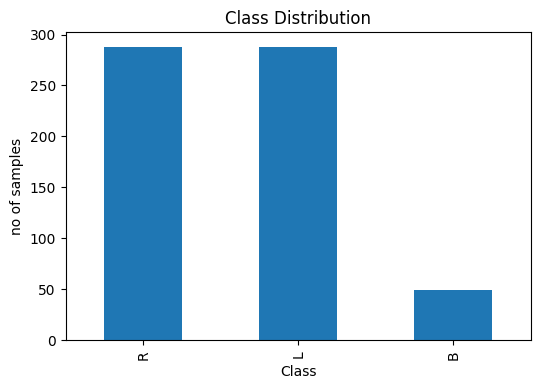

In [12]:
plt.figure(figsize=(6,4))
class_count.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("no of samples")
plt.show()

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [15]:
model=DecisionTreeClassifier()
model.fit(x_train,y_train)

GaussianNB()

In [35]:
print("\n Class Priors P(ci): ")
# print(model.class_prior_)


 Class Priors P(ci): 


In [37]:
print("\n Per_Class Feature means: ")
print(model.theta_)

print("\n per_class Feature Variances: ")
print(model.var_)


 Per_Class Feature means: 
[[3.12903226 3.         3.12903226 3.        ]
 [3.625      3.61538462 2.40384615 2.42788462]
 [2.37878788 2.38383838 3.63131313 3.65656566]]

 per_class Feature Variances: 
[[1.85431842 2.12903226 2.37044745 1.61290323]
 [1.41706731 1.5443787  1.85613906 1.75441476]
 [1.77066116 1.751658   1.52568616 1.41740639]]


In [18]:
y_pred=model.predict(x_test)
y_pred

array(['R', 'L', 'L', 'R', 'L', 'L', 'R', 'L', 'L', 'R', 'R', 'R', 'L',
       'L', 'L', 'L', 'R', 'L', 'R', 'L', 'R', 'R', 'R', 'L', 'L', 'L',
       'R', 'L', 'L', 'L', 'L', 'R', 'R', 'L', 'R', 'L', 'L', 'L', 'L',
       'R', 'L', 'R', 'R', 'L', 'R', 'R', 'L', 'R', 'R', 'R', 'L', 'L',
       'R', 'R', 'L', 'L', 'R', 'L', 'L', 'L', 'L', 'L', 'R', 'R', 'L',
       'L', 'R', 'R', 'L', 'L', 'R', 'R', 'R', 'R', 'R', 'L', 'L', 'R',
       'L', 'R', 'R', 'L', 'R', 'L', 'R', 'L', 'L', 'L', 'R', 'L', 'L',
       'L', 'R', 'L', 'L', 'R', 'R', 'R', 'R', 'R', 'L', 'L', 'R', 'R',
       'L', 'L', 'L', 'R', 'R', 'L', 'R', 'L', 'R', 'R', 'L', 'R', 'L',
       'L', 'L', 'L', 'R', 'R', 'L', 'L', 'R', 'R', 'R', 'R', 'R', 'R',
       'L', 'L', 'L', 'R', 'L', 'L', 'L', 'R', 'L', 'L', 'L', 'R', 'R',
       'R', 'L', 'R', 'R', 'L', 'R', 'R', 'R', 'R', 'R', 'L', 'R', 'R',
       'L', 'L', 'R', 'L', 'L', 'R', 'R', 'L', 'L', 'L', 'R', 'L', 'R',
       'L', 'L', 'R', 'R', 'R', 'L', 'L', 'L', 'L', 'R', 'L', 'R

In [39]:
cm=confusion_matrix(y_test,y_pred)
print("\n  confusion matrix")
print(cm)


  confusion matrix
[[ 0 13  5]
 [ 0 80  0]
 [ 0  3 87]]


In [41]:
accuracy=accuracy_score(y_test,y_pred)
print("\n Accuracy: ",accuracy)
print(f"{accuracy * 100:.2f}%")



 Accuracy:  0.8882978723404256
88.83%


In [ ]:
print("\n classification report")
print(classification_report(y_test,y_pred))

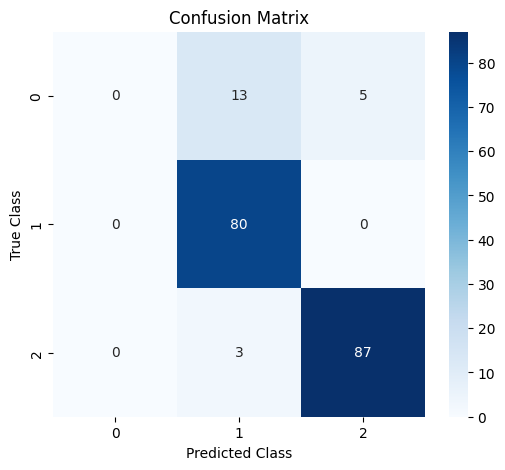

In [43]:
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()